In [1]:
from pathlib import Path

with open(Path() / "data" / "pixar.txt") as pixar_file:
    content = pixar_file.read()

print(len(content))

1801634


In [3]:
d_vocab = 512
d_embedding = 32
d_model = 512
n_layers = 2
context_len = 100

In [25]:
import torch
from tokenizer import TokenizerBPE

tokenizer = TokenizerBPE(name=str(d_vocab), vocab_size=d_vocab)
data = torch.tensor(tokenizer.encode(content))

a = int(0.9 * len(data))
train_set = data[:a]
valid_set = data[a:]

In [37]:
def get_batch(split: str, context_len: int, batch_size: int):
    data_set = train_set if split == "train" else valid_set
    max_rand = len(data_set) - context_len - 1
    offsets = torch.randint(max_rand, size=(batch_size, ))
    x = [data_set[offset:offset+context_len] for offset in offsets]
    y = [data_set[offset+1:offset+context_len+1] for offset in offsets]
    return torch.stack(x), torch.stack(y)

In [51]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [52]:
from model import PixarModel

pixar_model = PixarModel(
    d_vocab=d_vocab,
    d_embedding=d_embedding,
    d_model=d_model,
    n_layers=n_layers,
).to(device)


In [53]:
batch_size = 32

In [58]:
from torch.optim.adamw import AdamW

optimizer = AdamW(
    pixar_model.parameters(),
    lr=0.001,
)

In [67]:
torch.no_grad()
def evaluate(model: PixarModel, times, set_type):
    model.eval()

    loss_acc = torch.tensor(0.0, device=device)
    for _ in range(times):
        x, y = get_batch(set_type, context_len, batch_size)
        x = x.to(device)
        y = y.to(device)
        logits = pixar_model(x)

        loss = F.cross_entropy(
            logits.reshape(-1, logits.size(-1)),
            y.reshape(-1),
        )
        loss_acc += loss

    model.train()
    return (loss_acc / times).item()


In [68]:
import torch.nn.functional as F

epochs = 10_000
eval_every = 100
eval_on = 10

pixar_model.train()

lossi = []

for epoch in range(epochs):
    x, y = get_batch("train", context_len, batch_size)
    x = x.to(device)
    y = y.to(device)
    logits = pixar_model(x)

    loss = F.cross_entropy(
        logits.reshape(-1, logits.size(-1)),
        y.reshape(-1),
    )
    lossi.append(loss.item())

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    if epoch % eval_every == 0:
        train_loss= evaluate(pixar_model, eval_on, "train")
        valid_loss= evaluate(pixar_model, eval_on, "valid")
        print(f"{epoch}/{epochs}  train = {train_loss:.4f}, valid = {valid_loss:.4f}")


0/10000  train = 4.1851, valid = 4.1394
100/10000  train = 3.6994, valid = 3.7011
200/10000  train = 3.3455, valid = 3.2820
300/10000  train = 2.9983, valid = 3.0050
400/10000  train = 2.8130, valid = 2.8428
500/10000  train = 2.6652, valid = 2.7419
600/10000  train = 2.5257, valid = 2.6546
700/10000  train = 2.4178, valid = 2.5354
800/10000  train = 2.3110, valid = 2.5294
900/10000  train = 2.2629, valid = 2.5041
1000/10000  train = 2.2029, valid = 2.4012
1100/10000  train = 2.1586, valid = 2.4200
1200/10000  train = 2.1051, valid = 2.3788
1300/10000  train = 2.0766, valid = 2.3387
1400/10000  train = 2.0331, valid = 2.3869
1500/10000  train = 1.9780, valid = 2.3445
1600/10000  train = 2.0056, valid = 2.2794
1700/10000  train = 1.9314, valid = 2.3503
1800/10000  train = 1.9465, valid = 2.3124
1900/10000  train = 1.8758, valid = 2.3167
2000/10000  train = 1.8976, valid = 2.2928
2100/10000  train = 1.8270, valid = 2.3484
2200/10000  train = 1.7882, valid = 2.3318
2300/10000  train = 1.8

In [69]:
torch.save(pixar_model.state_dict(), "pixar_model.pt")

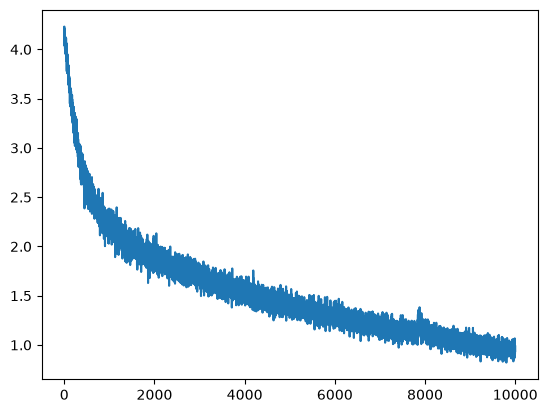

In [70]:
import matplotlib.pyplot as plt

plt.plot(lossi)

In [71]:
@torch.no_grad()
def generate(
    model: PixarModel,
    tokenizer,
    prompt: str,
    max_new_tokens: int,
    context_len: int,
    device: str,
) -> str:
    model.eval()

    tokens = tokenizer.encode(prompt) if prompt else [0]  # jeśli pusty prompt, zacznij od jakiegoś tokenu
    x = torch.tensor([tokens], device=device)               # (1, T)

    for _ in range(max_new_tokens):
        x_cond = x[:, -context_len:]   # przytnij do ostatnich context_len tokenów (model nie widział dłuższych)
        logits = model(x_cond)          # (1, T', d_vocab)
        next_token_logits = logits[0, -1]
        next_token = next_token_logits.argmax(dim=-1).item()
        x = torch.cat([x, torch.tensor([[next_token]], device=device)], dim=1)

    model.train()
    return tokenizer.decode(x[0].tolist())

In [72]:
def generate_to_file(
    model: PixarModel,
    tokenizer,
    prompt: str,
    total_tokens: int,
    context_len: int,
    device: str,
    output_path: str,
    chunk_size: int = 200,
) -> None:
    model.eval()

    tokens = tokenizer.encode(prompt) if prompt else [0]
    x = torch.tensor([tokens], device=device)

    with open(output_path, "w", encoding="utf-8") as f:
        f.write(prompt)

        generated_count = 0
        with torch.no_grad():
            while generated_count < total_tokens:
                n = min(chunk_size, total_tokens - generated_count)
                new_tokens = []

                for _ in range(n):
                    x_cond = x[:, -context_len:]
                    logits = model(x_cond)
                    next_token = logits[0, -1].argmax(dim=-1).item()
                    x = torch.cat([x, torch.tensor([[next_token]], device=device)], dim=1)
                    new_tokens.append(next_token)

                f.write(tokenizer.decode(new_tokens))
                f.flush()   # od razu widać postęp w pliku, nie czekasz do końca
                generated_count += n

    model.train()
    print(f"Zapisano {generated_count} tokenów do {output_path}")

In [73]:
print(generate(pixar_model, tokenizer, prompt="Once upon a time", max_new_tokens=200, context_len=context_len, device=device))

Once upon a time ... 

BOB 

I'm sorry, Bob. Wait a minute, who is always been. 

BOB 

Well, I'm sorry. 

Another Toy Scare Floor hangs up the bags. 

They spill out and scampers around a control panel. 

MIKE (CONT'D) 

Buzz...? 

BUZZ 

Woody, this is just like the professor view. 

Mike and Sullivan t


In [74]:
generate_to_file(
    pixar_model, tokenizer,
    prompt="Once upon a time",
    total_tokens=5000,
    context_len=context_len,
    device=device,
    output_path="generated_pixar.txt",
)

Zapisano 5000 tokenów do generated_pixar.txt
